In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sqlite3
from IPython.display import display, Markdown
from pathlib import Path
import os
import math

# AISYNPHYS stuff
import pyqtgraph
import neuroanalysis
import neuroanalysis.util
import aisynphys
import aisynphys.database

# Prints
print(aisynphys.__file__)
print(pyqtgraph.__file__)
print(neuroanalysis.__file__)

# Load matplotlib style
plt.style.use('plos.mplstyle')

# File path handling
# SCRIPT_DIR = Path(__file__).resolve().parent  # .py
SCRIPT_DIR = Path.cwd()  # .ipynb
FIGURES_DIR = SCRIPT_DIR / "figures_analysis"
print(f"Figure path: {FIGURES_DIR}")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------

# Load DB
from aisynphys.database import SynphysDatabase # https://aisynphys.readthedocs.io/en/current-release/database_access.html#database-access



CACHE_PATH = Path("data/aisynphys/cache").resolve()  # Define cache directory
CACHE_PATH.mkdir(parents=True, exist_ok=True)  # Create a cache directory if it does not exist
aisynphys.config.cache_path = CACHE_PATH  # Tell AISynPhys to use this cache
DATA_ROOT = Path("data/aisynphys/cache")  # Make cache
SynphysDatabase.list_versions()  # List all available versions


# DB_VERSION = 'synphys_r2.1_medium.sqlite'  # Medium database
DB_VERSION = 'synphys_r2.1_full.sqlite'  # Full database

db = SynphysDatabase.load_version(DB_VERSION)  # Load DB
print(f"Loaded version: {DB_VERSION}")

# ------------------------------------------------------------
# Set up connection


# DB_PATH = Path('data/aisynphys/cache/database/synphys_r2.1_medium.sqlite').resolve()  # Medium database
DB_PATH = Path('data/aisynphys/cache/database/synphys_r2.1_full.sqlite').resolve()  # Full database
assert DB_PATH.exists(), f"Database file not found: {DB_PATH}"  # Ensure existence


con = sqlite3.connect(DB_PATH)  # Create SQLite connection to SQLite database
con.create_function("SQRT", 1, math.sqrt)   # now SQLite understands SQRT()
cur = con.cursor()  # database cursor
print(f"Connection set up to {DB_PATH}")

C:\Users\snrambo\aisynphys\aisynphys\__init__.py
c:\Users\snrambo\AppData\Local\miniconda3\envs\aisynphys39\lib\site-packages\pyqtgraph\__init__.py
C:\Users\snrambo\neuroanalysis\neuroanalysis\__init__.py
Figure path: c:\Users\snrambo\Projects\NEVR3901\HeterogenousRNN\HeterogeneousRNNs\data_analysis\figures_analysis
Loaded version: synphys_r2.1_full.sqlite
Connection set up to C:\Users\snrambo\Projects\NEVR3901\HeterogenousRNN\HeterogeneousRNNs\data_analysis\data\aisynphys\cache\database\synphys_r2.1_full.sqlite


Loading all matrices

In [2]:
query = """ 
            SELECT 
                p.experiment_id,
                COUNT(*) AS total_pairs,
                SUM(p.has_synapse) AS num_synapses,
                COUNT(*) - SUM(p.has_synapse) AS num_no_synapses


            FROM pair p
            INNER JOIN cell       AS pre   ON p.pre_cell_id  = pre.id  
            INNER JOIN cell       AS post  ON p.post_cell_id = post.id
            INNER JOIN intrinsic  AS i_pre ON p.pre_cell_id  = i_pre.cell_id
            INNER JOIN intrinsic  AS i_post ON p.post_cell_id = i_post.cell_id
            LEFT JOIN synapse AS syn   ON syn.pair_id = p.id          -- can be NULL
            INNER JOIN experiment AS e     ON e.id = p.experiment_id
            INNER JOIN slice      AS s     ON e.slice_id = s.id


            WHERE 
                s.species = 'mouse'
                AND i_pre.fi_slope IS NOT NULL
                AND i_post.fi_slope IS NOT NULL
                AND p.has_synapse IS NOT NULL   -- only defined synapses
                AND syn.psp_amplitude IS NOT NULL
                
                AND (p.has_synapse = 0 OR (p.has_synapse = 1 AND syn.psp_amplitude IS NOT NULL))  -- no included synapses where there is nan value in psp amplitude
                
            GROUP BY p.experiment_id
            HAVING num_synapses > 1
            ;
        """

experiments = pd.read_sql_query(query, con)

unique_exp = experiments["experiment_id"].unique()
print(f"Number of experiments in the grouped DF: {len(unique_exp)}")

experiment_ids = experiments["experiment_id"].unique().tolist()

print(len(experiment_ids))

for exp in experiment_ids:
    # Test
    print(f"EXPERIMENT: {exp}")
    adj = np.load(f"psp_arrays/experiment_{exp}.npy")
    print(f"  PSP Matrix of shape: {adj.shape}")

# From here, can do motif analysis on PSP Matrix

Number of experiments in the grouped DF: 140
140
EXPERIMENT: 600
  PSP Matrix of shape: (3, 3)
EXPERIMENT: 727
  PSP Matrix of shape: (4, 4)
EXPERIMENT: 793
  PSP Matrix of shape: (5, 5)
EXPERIMENT: 900
  PSP Matrix of shape: (3, 3)
EXPERIMENT: 901
  PSP Matrix of shape: (5, 5)
EXPERIMENT: 1008
  PSP Matrix of shape: (3, 3)
EXPERIMENT: 1036
  PSP Matrix of shape: (4, 4)
EXPERIMENT: 1077
  PSP Matrix of shape: (2, 2)
EXPERIMENT: 1124
  PSP Matrix of shape: (3, 3)
EXPERIMENT: 1260
  PSP Matrix of shape: (2, 2)
EXPERIMENT: 1297
  PSP Matrix of shape: (3, 3)
EXPERIMENT: 1436
  PSP Matrix of shape: (3, 3)
EXPERIMENT: 1443
  PSP Matrix of shape: (3, 3)
EXPERIMENT: 1461
  PSP Matrix of shape: (3, 3)
EXPERIMENT: 1473
  PSP Matrix of shape: (3, 3)
EXPERIMENT: 1477
  PSP Matrix of shape: (2, 2)
EXPERIMENT: 1485
  PSP Matrix of shape: (4, 4)
EXPERIMENT: 1488
  PSP Matrix of shape: (3, 3)
EXPERIMENT: 1511
  PSP Matrix of shape: (2, 2)
EXPERIMENT: 1521
  PSP Matrix of shape: (4, 4)
EXPERIMENT: 1544

In [4]:
df = pd.read_csv("psp_metadata\experiment_3263_cell_metadata.csv")
df

,experiment_id,cell_id,matrix_index,cell_class,cre_type,fi_slope,appears_as_pre,appears_as_post,n_outgoing_pairs,n_incoming_pairs,n_outgoing_synapses,n_incoming_synapses,n_outgoing_no_synapse,n_incoming_no_synapse
0,3263,18573,0,in,pvalb,4.743240e-13,True,True,3,3,0,3,3,0
1,3263,18574,1,mixed,pvalb,4.405672e-13,True,True,2,3,2,0,0,3
2,3263,18575,2,in,pvalb,5.278912e-13,True,True,3,2,1,1,2,1
3,3263,18576,3,in,pvalb,4.672410e-13,True,True,2,2,1,0,1,2


Counting motifs: For these, we need the original dataframe, containing the has_synapse column.

In [ ]:
from itertools import combinations
def count_reciprocal(df):
    ''' 
    Maps whether synapses exist in each direction
     
    '''
    connectivity = set(map(tuple, df[['pre_cell_id','post_cell_id']].values))
    rec = 0

    # Iterate over unordered combinations of pairs of neurons (take combinations, then count pairs of connections only once)

    neurons = df['pre_cell_id'].unique()
    for a, b in combinations(neurons, 2):
        # Does A→B and B→A exist?
        if (a,b) in connectivity and (b,a) in connectivity:
            rec += 1

    return rec


def count_divergent(df):
    ''' 
    For each presynaptic, look at its posts and choose pairs of posts  
    '''
    div = 0
    for pre, subdf in df.groupby('pre_cell_id'):
        posts = subdf['post_cell_id'].unique()
        for post1, post2 in combinations(posts, 2):
            if post1 == post2 or post1 == pre or post2 == pre:
                continue
            div += 1

    return div


def count_convergent(df):
    '''
    For each postsynaptic, look at its pres and choose pairs of pres
    '''
    con = 0
    for post, subdf in df.groupby('post_cell_id'):
        pres = subdf['pre_cell_id'].unique()
        for pre1, pre2 in combinations(pres, 2):
            if pre1 == post or pre2 == post:
                continue
            con += 1

    return con


def count_chain(df):
    '''
    Gamma is an intermediate node: it appears as a post in one connection and a pre in another
    '''
    chn = 0
    for gamma in set(df['pre_cell_id']).intersection(df['post_cell_id']):
        ins  = df[df['post_cell_id']==gamma]  # conexiones pre→gamma
        outs = df[df['pre_cell_id']==gamma]   # conexiones gamma→post
        pres = ins['pre_cell_id'].unique()
        posts = outs['post_cell_id'].unique()
        # Combina cada pre con cada post
        for pre, post in ((p, q) for p in pres for q in posts):
            if pre in (gamma, post) or post in (gamma, pre):
                continue
            chn += 1

    return chn




In [ ]:
def safe_divide(n, d):
    '''Returns np.nan if the denominator is zero'''
    return n / d if d != 0 else np.nan

def compute_tau(count_motif, count_possible, sigma2, p):
    '''Compute tau'''
    p_motif = safe_divide(count_motif,count_possible)
    return safe_divide((p_motif-p**2),sigma2)

def compute_motifs(df):

    '''
    This function computes the motifs by utilizing the other functions.
    It first get counts of possible motifs.
    It then computes motifs that actually occurred.
    It then computes p (overall connection probability).
    It then calculate sigma^2.
    Finally, it passes these to the function that computes tau (the z score), and return that.
    '''

    # Possible motif count

    possible_rec = count_reciprocal(df)
    possible_div = count_divergent(df)
    possible_con = count_convergent(df)
    possible_chn = count_chain(df)

    # Actual motif count

    df_syn = df[df['has_synapse'] == 1]

    rec_count = count_reciprocal(df_syn)
    div_count = count_divergent(df_syn)
    con_count = count_convergent(df_syn)
    chn_count = count_chain(df_syn)


    # Return nan if no synapses

    if len(df_syn) == 0:
        return (np.nan, np.nan, np.nan, np.nan)
    
    
    # calculate p

    p = len(df_syn) / len(df)  
    
    # calculate sigma^2

    sigma2 = p * (1 - p)  

    # Get tau (z-score)

    tau_rec = compute_tau(rec_count, possible_rec, sigma2, p)
    tau_div = compute_tau(div_count, possible_div, sigma2, p)
    tau_con = compute_tau(con_count, possible_con, sigma2, p)
    tau_chn = compute_tau(chn_count, possible_chn, sigma2, p)
   

    # Return tau (z-score)
    return tau_rec, tau_div, tau_con, tau_chn

# df = pd.read_csv('preprocessed_data_multiplecategories_noneg.csv')  # Has header
# dfA = df.copy()
# tau_rec, tau_div, tau_con, tau_chn = compute_motifs(dfA)

PSP Matrix motifs

In [14]:
# Convert the dataframe to a numpy array
# psp_matrix_numpy = df_psp_matrix.values

def motifs(w,N):
   '''
   Takes the psp matrix, and how many neurons, and perform motif calculations
   
   '''
   w=w-np.mean(w)
   ww=np.matmul(w,w)
   wtw=np.matmul(w.T,w)
   wwt=np.matmul(w,w.T)
   sigma2=np.trace(wwt)/N
   tau_rec=np.trace(ww)
   tau_rec/=sigma2*N
   tau_div=np.sum(wwt)-np.trace(wwt)
   tau_div/=sigma2*N*(N-1)
   tau_con=np.sum(wtw)-np.trace(wtw)
   tau_con/=sigma2*N*(N-1)
   tau_chn=2*(np.sum(ww)-np.trace(ww))
   tau_chn/=sigma2*N*(N-1)
   return tau_rec,tau_div,tau_con,tau_chn


def motifs_zero_filled(w, N):
    """
    Same as original function, but first replace NaNs by 0.
    """
    #  Replace missing entries by 0 (no connection)
    w = np.nan_to_num(w, nan=0.0)

    # Center the matrix using the *overall* mean (now a finite number)
    w = w - np.mean(w)


    ww = np.matmul(w, w)
    wtw = np.matmul(w.T, w)
    wwt = np.matmul(w, w.T)
    sigma2 = np.trace(wwt) / N

    tau_rec = np.trace(ww) / (sigma2 * N)
    tau_div = (np.sum(wwt) - np.trace(wwt)) / (sigma2 * N * (N - 1))
    tau_con = (np.sum(wtw) - np.trace(wtw)) / (sigma2 * N * (N - 1))
    tau_chn = 2 * (np.sum(ww) - np.trace(ww)) / (sigma2 * N * (N - 1))

    return tau_rec, tau_div, tau_con, tau_chn


def motifs_nan_aware(w, N):
    """
    Compute the motif scores while ignoring NaNs when calculating the mean.
    Unmeasured entries are treated as 0 after the centering step.
    """
    # Compute the mean over the *observed* entries only
    w_centered = w - np.nanmean(w)          # nan‑safe mean

    # Replace any still‑nan entries (the ones that were never measured) by 0 so that the matrix algebra can continue.
    w_centered = np.nan_to_num(w_centered, nan=0.0)

    # Continue with the original algebra
    ww = np.matmul(w_centered, w_centered)
    wtw = np.matmul(w_centered.T, w_centered)
    wwt = np.matmul(w_centered, w_centered.T)

    sigma2 = np.trace(wwt) / N

    tau_rec = np.trace(ww) / (sigma2 * N)

    tau_div = (np.sum(wwt) - np.trace(wwt)) / (sigma2 * N * (N - 1))

    tau_con = (np.sum(wtw) - np.trace(wtw)) / (sigma2 * N * (N - 1))

    tau_chn = 2 * (np.sum(ww) - np.trace(ww)) / (sigma2 * N * (N - 1))

    return tau_rec, tau_div, tau_con, tau_chn


In [57]:
rows = []

for exp in experiment_ids:
    # Test
    # print(f"EXPERIMENT: {exp}")
    adj = np.load(f"psp_arrays/experiment_{exp}.npy")
    # print(f"  PSP Matrix of shape: {adj.shape}")

    meta_df = pd.read_csv(f"psp_metadata/experiment_{exp}_fi_slopes.csv")
    fi_mean = meta_df["fi_slope"].mean()

    num_measured = np.count_nonzero(~np.isnan(adj))
    fraction_measured = np.count_nonzero(~np.isnan(adj)) / adj.size

    # tau_rec, tau_div, tau_con, tau_chn = motifs_nan_aware(psp_matrix_numpy, len(all_cells))
    tau_rec, tau_div, tau_con, tau_chn = motifs_zero_filled(adj, adj.shape[0])

    row = [exp, adj.shape[0], fi_mean, num_measured, fraction_measured, tau_rec, tau_div, tau_con, tau_chn]
    rows.append(row)

        
for r in rows:
    print(r)

columns = ['experiment', 'popsize', 'postsynaptic_fi', 'num_measured', 'fraction_measured', 'tau_rec', 'tau_div', 'tau_con', 'tau_chn']
df = pd.DataFrame(rows, columns=columns)

df

[600, 3, np.float64(6.803838821920388e-13), 2, 0.2222222222222222, np.float64(-0.0275916591345943), np.float64(-0.027591659134594316), np.float64(-0.027591659134594316), np.float64(-0.44481668173081135)]
[727, 4, np.float64(1.2893716706783817e-13), 2, 0.125, np.float64(-0.1323125145908068), np.float64(-0.1323125145908068), np.float64(-0.1323125145908068), np.float64(-0.2646250291816136)]
[793, 5, np.float64(2.91288113892957e-13), 6, 0.24, np.float64(-0.016735252672069965), np.float64(-0.14462967178698946), np.float64(0.11321345493468583), np.float64(-0.1307579801751633)]
[900, 3, np.float64(4.885714196739235e-13), 3, 0.3333333333333333, np.float64(0.40649476534239676), np.float64(-0.21398654743672557), np.float64(-0.17814364670703556), np.float64(-0.41811046224579995)]
[901, 5, np.float64(3.9382237153052735e-14), 4, 0.16, np.float64(-0.0027137335669937127), np.float64(-0.002713733566993725), np.float64(0.025096837108930303), np.float64(-0.3485542941388375)]
[1008, 3, np.float64(4.29761

,experiment,popsize,postsynaptic_fi,num_measured,fraction_measured,tau_rec,tau_div,tau_con,tau_chn
0,600,3,6.803839e-13,2,0.222222,-0.027592,-0.027592,-0.027592,-0.444817
1,727,4,1.289372e-13,2,0.125000,-0.132313,-0.132313,-0.132313,-0.264625
2,793,5,2.912881e-13,6,0.240000,-0.016735,-0.144630,0.113213,-0.130758
3,900,3,4.885714e-13,3,0.333333,0.406495,-0.213987,-0.178144,-0.418110
4,901,5,3.938224e-14,4,0.160000,-0.002714,-0.002714,0.025097,-0.348554
...,...,...,...,...,...,...,...,...,...
135,4816,3,7.662407e-13,2,0.222222,-0.054701,-0.054701,-0.054701,-0.390598
136,4907,2,6.190401e-13,2,0.500000,-0.848076,-0.075962,-0.075962,-0.151924
137,4935,3,3.306400e-13,2,0.222222,-0.219995,0.159986,-0.219995,-0.439991
138,4942,2,4.484898e-13,2,0.500000,0.825202,-0.912601,-0.912601,-1.825202


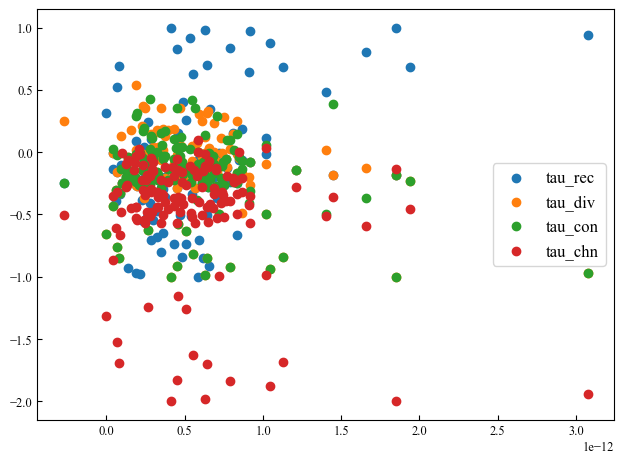

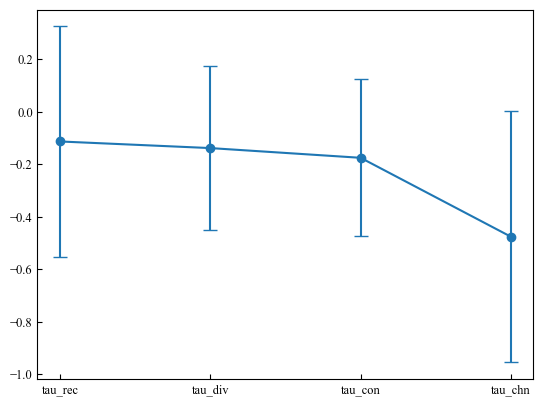

In [ ]:
motifs = ['tau_rec', 'tau_div', 'tau_con', 'tau_chn']


ys = []
yerrs = []

fig, ax = plt.subplots()

for m in motifs:


    ys.append(df[m].mean())
    yerrs.append(df[m].std())  # sample std by default

    df_xy = df[[m, 'postsynaptic_fi']]

    ax.scatter(df_xy["postsynaptic_fi"], df_xy[m], label=m)

plt.legend()
plt.tight_layout()
plt.show()





fig, ax = plt.subplots()
ax.errorbar(motifs, ys, yerrs, capsize=5, fmt='o-')
plt.show()

# print(motif_fi)

# for key, values in motif_fi.items():
    
#     ax.hist(values, bins='auto', label=m)

# plt.legend()
# plt.show()


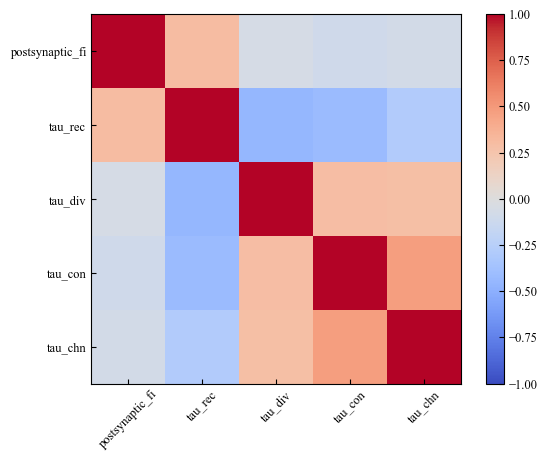

In [31]:
cols = ["postsynaptic_fi",
        "tau_rec",
        "tau_div",
        "tau_con",
        "tau_chn"]

corr = df[cols].corr(method="spearman")

plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.xticks(range(len(cols)), cols, rotation=45)
plt.yticks(range(len(cols)), cols)
plt.colorbar()

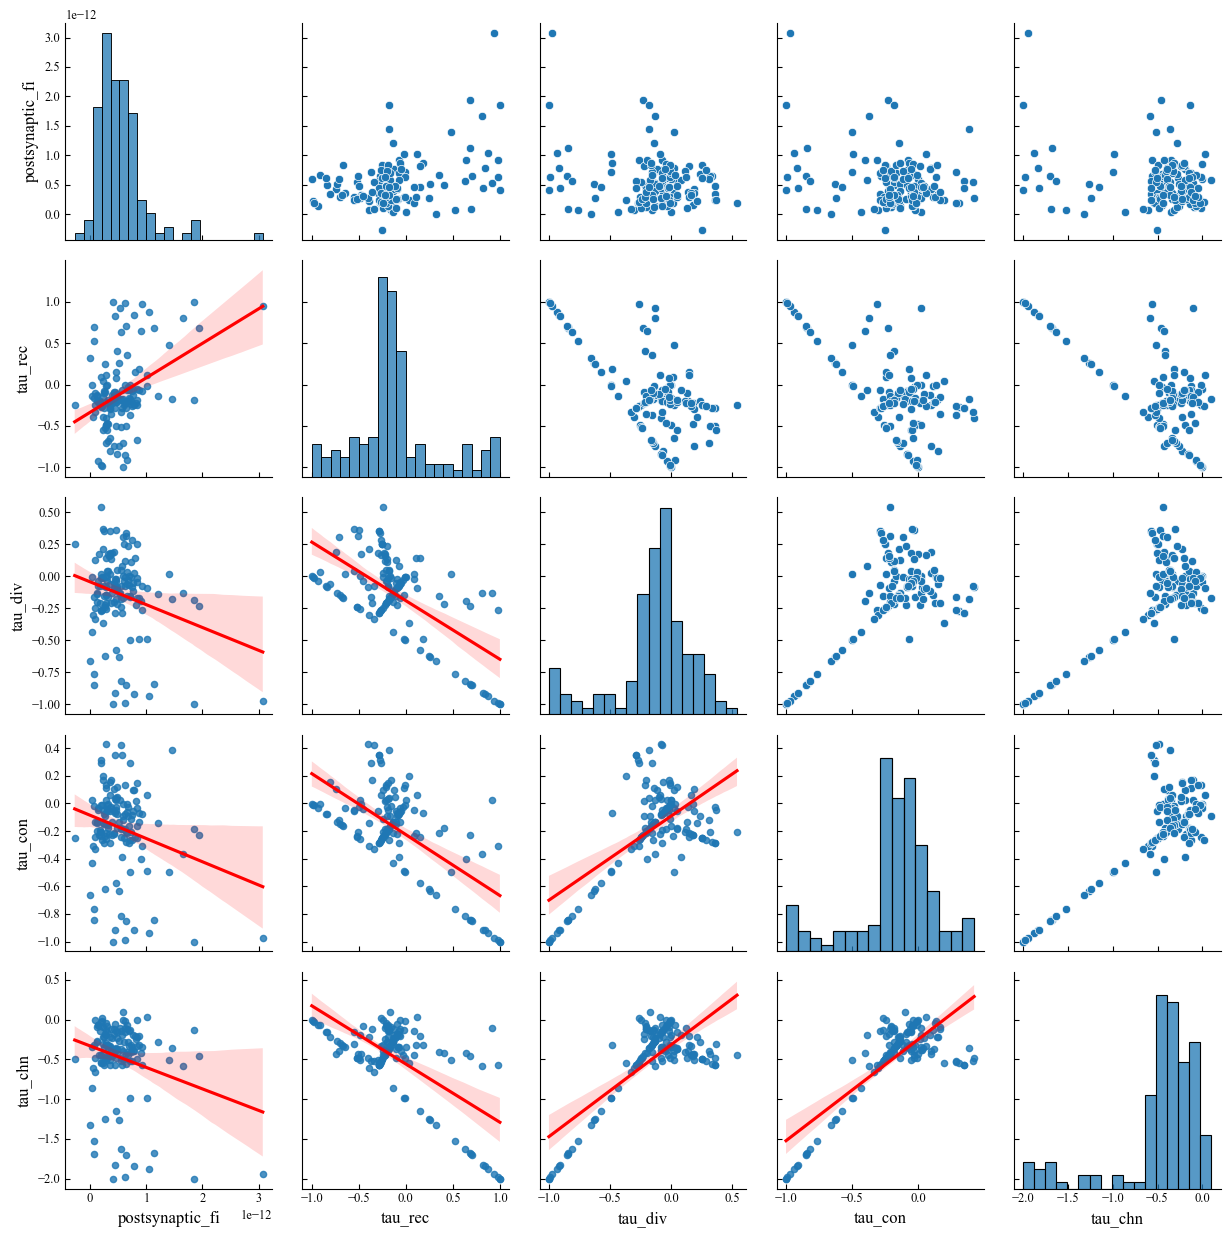

In [49]:
import seaborn as sns

g = sns.PairGrid(df[cols])
g.map_upper(sns.scatterplot)
g.map_lower(sns.regplot, scatter_kws={"s": 20}, line_kws={"color": "red"})
g.map_diag(sns.histplot)

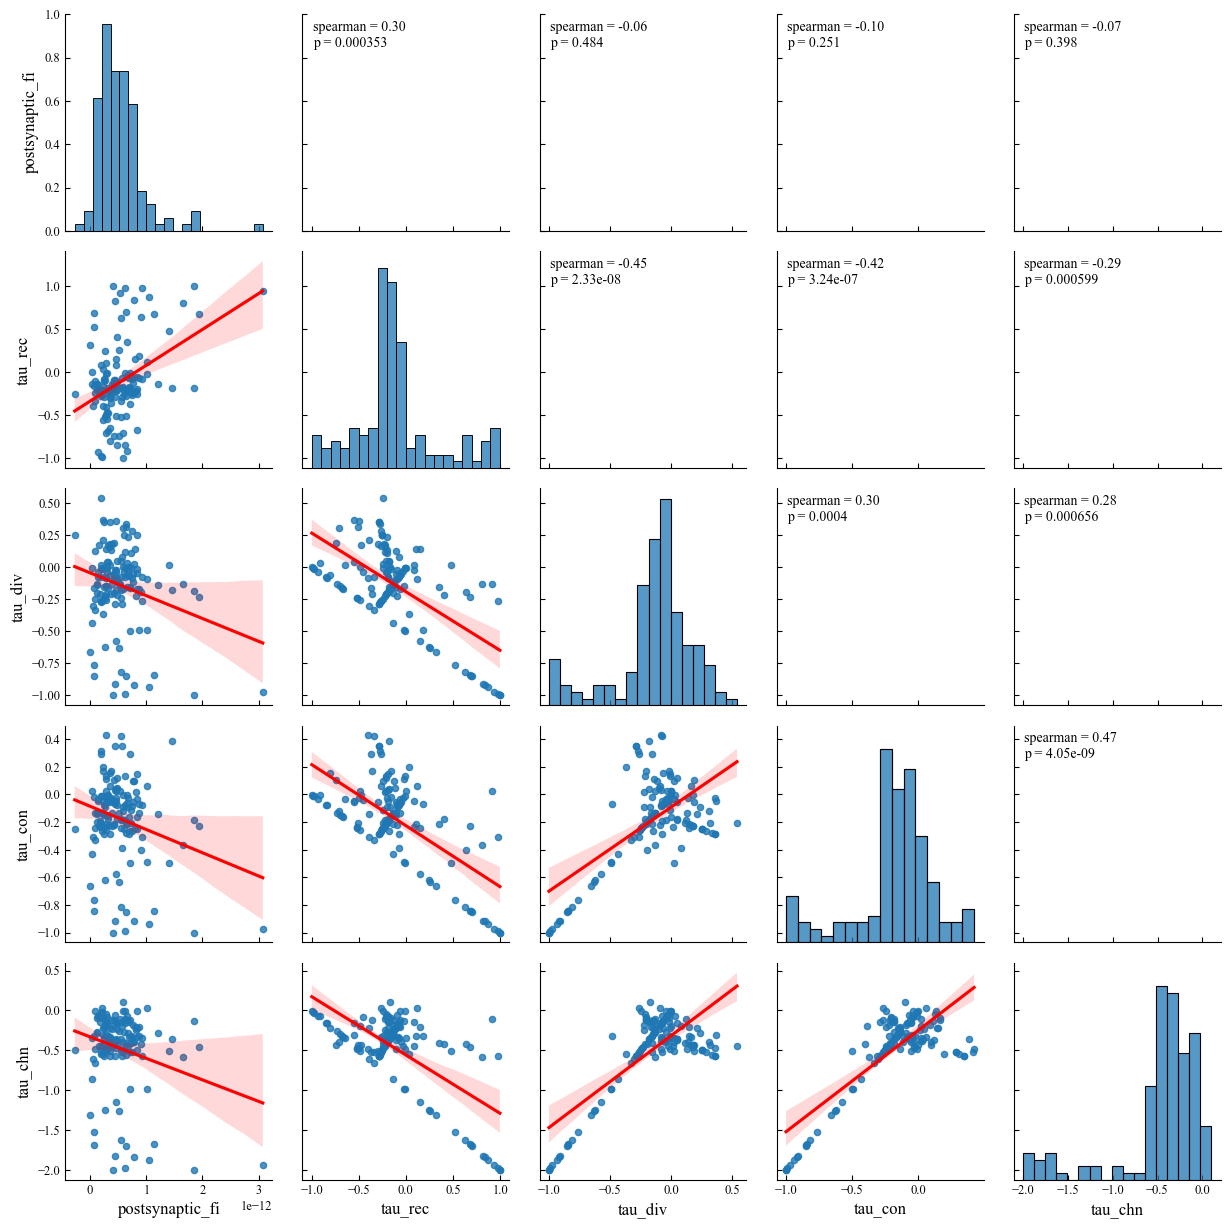

In [52]:
from scipy.stats import pearsonr

from scipy.stats import spearmanr

def corrfunc(x, y, **kws):
    rho, p = spearmanr(x, y)
    ax = plt.gca()
    ax.annotate(
        f"spearman = {rho:.2f}\np = {p:.3g}",
        xy=(0.05, 0.85),
        xycoords=ax.transAxes,
        fontsize=10
    )

g = sns.PairGrid(df[cols])
g.map_upper(corrfunc)
g.map_lower(sns.regplot, scatter_kws={"s":20}, line_kws={"color":"red"})
g.map_diag(sns.histplot)

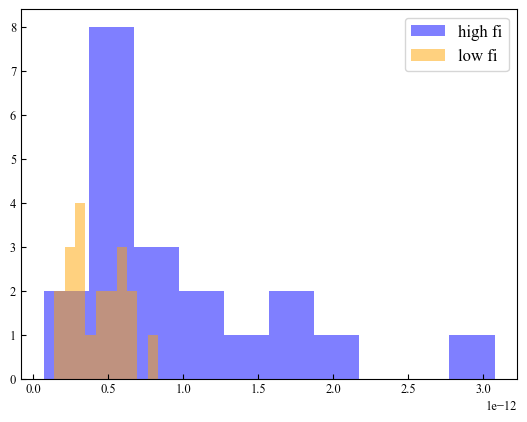

In [40]:
high = df.nlargest(20,"tau_rec")
low = df.nsmallest(20,"tau_rec")

plt.hist(high["postsynaptic_fi"], alpha=.5, color='blue', label='high fi')
plt.hist(low["postsynaptic_fi"], alpha=.5, color='orange', label='low fi')
plt.legend()

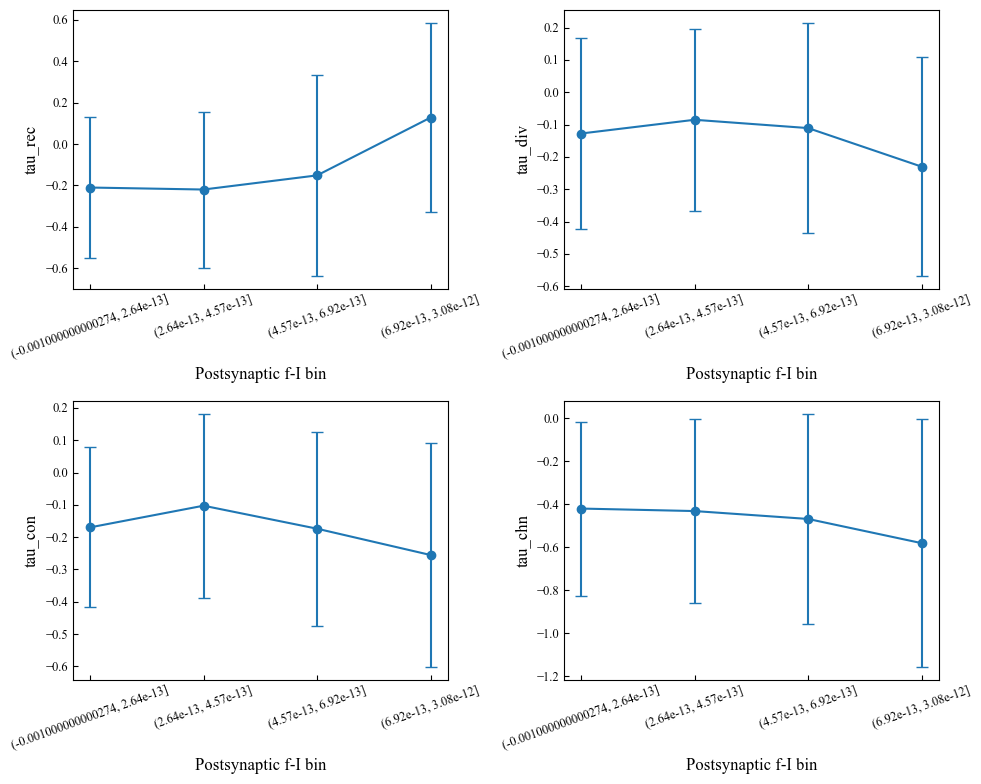

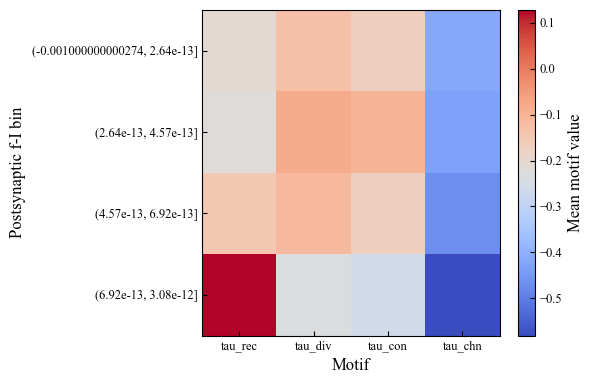

In [48]:
df["fi_bin"] = pd.qcut(df["postsynaptic_fi"], 4)

df

motifs = ["tau_rec", "tau_div", "tau_con", "tau_chn"]

fig, axs = plt.subplots(2,2, figsize=(10,8))

for ax, motif in zip(axs.ravel(), motifs):

    summary = (
        df.groupby("fi_bin", observed=True)[motif]
          .agg(["mean", "std"])
          .reset_index()
    )

    ax.errorbar(
        range(len(summary)),
        summary["mean"],
        yerr=summary["std"],
        marker="o",
        capsize=4
    )

    ax.set_xticks(range(len(summary)))
    ax.set_xticklabels(summary["fi_bin"], rotation=20)
    ax.set_ylabel(motif)
    ax.set_xlabel("Postsynaptic f-I bin")

plt.tight_layout()

# import seaborn as sns
# import matplotlib.pyplot as plt

# motifs = ["tau_rec", "tau_div", "tau_con", "tau_chn"]

# fig, axs = plt.subplots(2, 2, figsize=(10, 8))

# # for ax, motif in zip(axs.ravel(), motifs):
# #     sns.boxplot(
# #         data=df,
# #         x="fi_bin",
# #         y=motif,
# #         ax=ax
# #     )
# #     ax.set_xlabel("Postsynaptic f-I bin")
# #     ax.set_ylabel(motif)
# #     ax.tick_params(axis='x', rotation=20)

# # plt.tight_layout()

# for ax, motif in zip(axs.ravel(), motifs):
#     sns.violinplot(
#         data=df,
#         x="fi_bin",
#         y=motif,
#         ax=ax
#     )


# sns.stripplot(
#     data=df,
#     x="fi_bin",
#     y="tau_rec",
#     jitter=True
# )

motifs = ["tau_rec", "tau_div", "tau_con", "tau_chn"]

means = (
    df.groupby("fi_bin", observed=True)[motifs]
      .mean()
)

plt.figure(figsize=(6,4))
plt.imshow(means, cmap="coolwarm", aspect="auto")
plt.xticks(range(len(motifs)), motifs)
plt.yticks(range(len(means.index)), means.index)
plt.colorbar(label="Mean motif value")
plt.xlabel("Motif")
plt.ylabel("Postsynaptic f-I bin")
plt.tight_layout()